In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# EDA - Sebelum Preprocessing (data mentah)

In [2]:
# 1. Memuat Data
file_path = '/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/dataset/dataset_komentar_youtube_11k.csv'
df = pd.read_csv(file_path)

# 2. Observasi Informasi Dasar Data Mentah (Tanpa Cleaning)
print("=== INFO KONDISI DATA MENTAH ===")
print(f"Total baris awal: {df.shape[0]}")
print(f"Total kolom: {df.shape[1]}")

print("\n--- Jumlah Missing Values per Kolom ---")
print(df.isnull().sum())

print(f"\n--- Jumlah Baris Duplikat ---")
print(f"Ditemukan {df.duplicated().sum()} baris duplikat")

# 3. Menambahkan Fitur NLP (Observasi Karakter & Kata)
# Catatan: Menggunakan str() saat menghitung panjang untuk mencegah error jika ada NaN (missing value),
# tanpa perlu melakukan fillna() yang merubah data mentah asli.
df['char_count'] = df['comment_text'].apply(lambda x: len(str(x)))
df['word_count'] = df['comment_text'].apply(lambda x: len(str(x).split()))

# 4. Statistik Deskriptif (Untuk melihat outlier pada data mentah)
print("\n=== DESKRIPSI STATISTIK (RAW DATA) ===")
print(df[['like_count', 'char_count', 'word_count']].describe())

# 5. Visualisasi Data
sns.set_theme(style="whitegrid")

=== INFO KONDISI DATA MENTAH ===
Total baris awal: 11494
Total kolom: 6

--- Jumlah Missing Values per Kolom ---
video_id        0
comment_type    0
author          0
comment_text    1
like_count      0
published_at    0
dtype: int64

--- Jumlah Baris Duplikat ---
Ditemukan 1 baris duplikat

=== DESKRIPSI STATISTIK (RAW DATA) ===
         like_count    char_count    word_count
count  11494.000000  11494.000000  11494.000000
mean       1.641465     97.424134     14.966243
std       10.344478    124.101695     18.439049
min        0.000000      1.000000      1.000000
25%        0.000000     36.000000      6.000000
50%        0.000000     66.000000     10.000000
75%        0.000000    116.000000     18.000000
max      600.000000   2832.000000    436.000000


/tmp/ipykernel_3234/305510306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='comment_type', order=df['comment_type'].value_counts().index, palette='viridis')


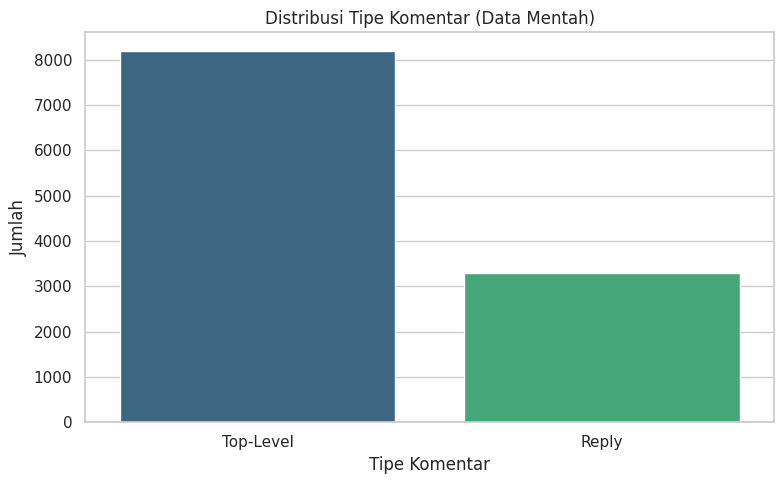

In [3]:
# --- Plot 1: Distribusi Tipe Komentar ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='comment_type', order=df['comment_type'].value_counts().index, palette='viridis')
plt.title('Distribusi Tipe Komentar (Data Mentah)')
plt.xlabel('Tipe Komentar')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

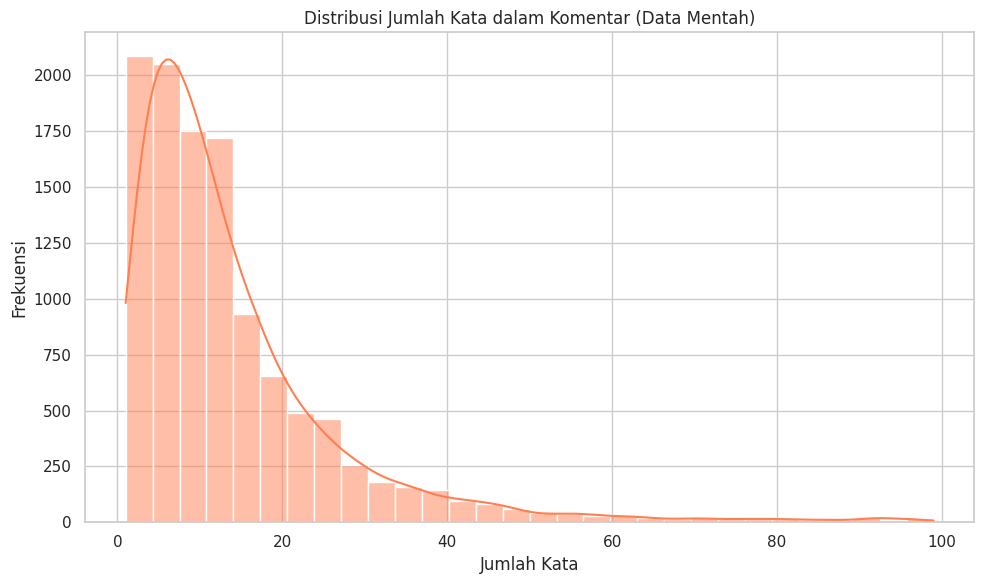

In [4]:
# --- Plot 2: Distribusi Jumlah Kata ---
plt.figure(figsize=(10, 6))
# Melakukan filter pada plot untuk rentang kata <= 100 agar distribusi data mayoritas terlihat jelas
# (Komentar outlier ratusan kata akan menyempitkan grafik jika tidak difilter)
sns.histplot(df[df['word_count'] <= 100]['word_count'], bins=30, kde=True, color='coral')
plt.title('Distribusi Jumlah Kata dalam Komentar (Data Mentah)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

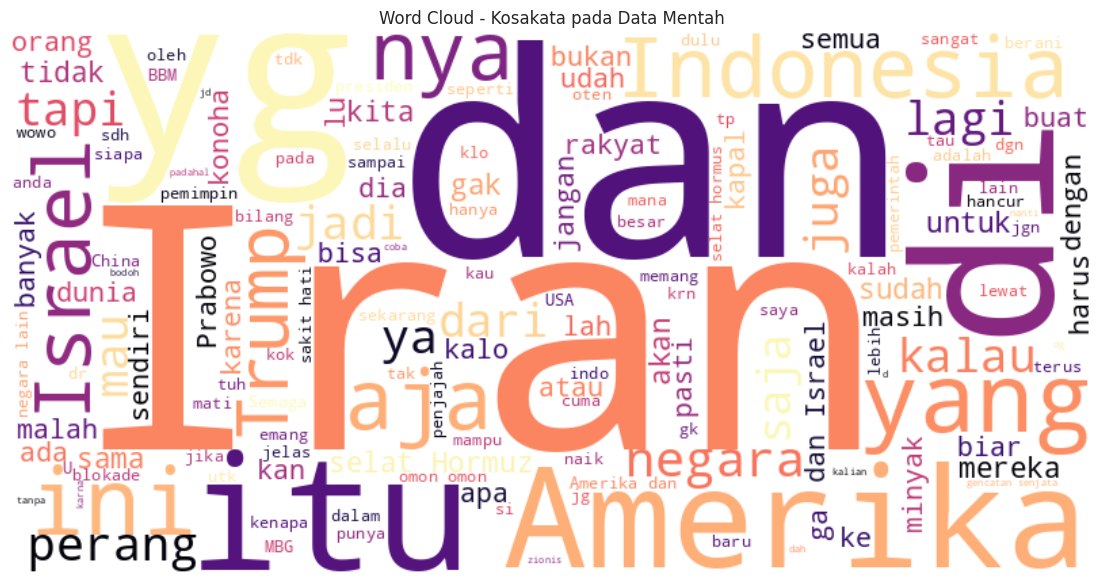

In [5]:
# --- Plot 3: Word Cloud (Kondisi Teks Sebelum Preprocessing) ---
plt.figure(figsize=(12, 6))
# df['comment_text'].dropna() digunakan HANYA saat generate WordCloud agar library tidak error
# Dataframe (df) tetap utuh beserta missing value-nya
text_for_cloud = ' '.join(df['comment_text'].dropna().astype(str).values)
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=150, colormap='magma').generate(text_for_cloud)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Kosakata pada Data Mentah')
plt.tight_layout()
plt.show()

# Prepocessing

In [6]:
import pandas as pd
import re

# ==========================================
# 1. PERSIAPAN KAMUS SLANG
# ==========================================
print("Memuat kamus slang...")
# Asumsi file memiliki kolom 'slang' (kata alay) dan 'baku' (kata perbaikan)
# Jika nama kolom di CSV kamu berbeda, silakan ubah 'slang' dan 'baku' di bawah ini
df_slang = pd.read_csv('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/dataset/slang_indonesia.csv')

# Ubah menjadi bentuk Dictionary agar pencarian jauh lebih cepat
# Pastikan semua kata di kamus diubah ke huruf kecil (lowercase) untuk pencocokan
slang_dict = dict(zip(df_slang['slang'].astype(str).str.lower(),
                      df_slang['formal'].astype(str).str.lower()))

Memuat kamus slang...


In [12]:
import pandas as pd
import re

# ==========================================
# 2. FUNGSI PREPROCESSING UTAMA
# ==========================================
def preprocess_text(text):
    if pd.isna(text):
        return ""

    # A. Case Folding (Ubah ke huruf kecil)
    text = str(text).lower()

    # B. Hapus Karakter Rusak (Imbas gagal scraping emoticon)
    # 1. Menghapus karakter Unicode replacement (biasanya muncul sebagai )
    # Perbaikan: Mengganti r'+' dengan r'\uFFFD' untuk menargetkan karakter unicode replacement.
    text = re.sub(r'\uFFFD', ' ', text)
    # 2. Menghapus semua karakter non-ASCII (menghapus sisa karakter aneh/huruf asing)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # C. Bersihkan Noise Internet
    text = re.sub(r'http\S+|www\.\S+', '', text) # Hapus URL/Link
    text = re.sub(r'<.*?>', '', text)            # Hapus tag HTML (seperti <br>)
    text = re.sub(r'@\w+', '', text)             # Hapus mention username (@username)

    # D. Normalisasi Tanda Baca untuk Transformer
    # 1. Hapus semua tanda baca KECUALI tanda seru (!) dan tanda tanya (?)
    text = re.sub(r'[^\w\s\?!]', ' ', text)

    # 2. CAPPING TANDA BACA (Batasi maksimal 2)
    # Jika ada ! atau ? yang berulang 2 kali atau lebih, potong menjadi 2 saja.
    text = re.sub(r'(!)\2+', r'!!!', text)
    text = re.sub(r'(\?)\2+', r'???', text)

    # E. Normalisasi Kata Slang / Alay (Sesuai file CSV)
    # Pecah kalimat menjadi daftar kata, ubah jika ada di kamus, lalu gabung lagi
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    text = ' '.join(normalized_words)

    # F. Memperbaiki Karakter Berulang
    # Mengubah 3 atau lebih karakter berurutan menjadi 1 karakter.
    # (Kita pakai angka 3 agar kata dengan 2 huruf berurutan yang sah seperti "maaf" tidak rusak menjadi "maf")
    # Contoh: "baguuuus" -> "bagus", "kereeeeen" -> "keren"
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1', text)

    # G. Rapikan Spasi (Hapus spasi ganda)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [13]:

# ==========================================
# 3. CARA PENGGUNAAN PADA DATASET YOUTUBE
# ==========================================
# Misalkan dataset komentarmu bernama "komentar_youtube.csv"
# dan kolom teksnya bernama "komentar"

# Silakan hapus tanda kutip (uncomment) blok ini untuk menjalankan di datamu:

print("Memuat dataset komentar...")
df = pd.read_csv('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/dataset/dataset_komentar_youtube_11k.csv')

# 1. Terapkan fungsi preprocessing ke kolom teks
print("Memulai preprocessing...")
df['clean_text'] = df['comment_text'].apply(preprocess_text)


Memuat dataset komentar...
Memulai preprocessing...


In [14]:
print("Hasil Preprocessing:")
display(df[['comment_text', 'clean_text']].head())

Hasil Preprocessing:
                                        comment_text  \
0  Penipu betul perempuan blonde ini. Sama dgn Tr...   
1  Tidak boleh diterima????? Tanpa rasa malu peny...   
2             Konoha konoha beritanya ngibul trus...   
3  PBB cm bisa mengecam doang tapi tidak bisa ber...   
4                                      Amerika rasis   

                                          clean_text  
0  penipu betul perempuan blonde ini sama dengan ...  
1  tidak boleh diterima????? tanpa rasa malu peny...  
2            konoha konoha beritanya berbohong terus  
3  pbb cuma bisa mengecam saja tapi tidak bisa be...  
4                                      amerika rasis  


In [15]:
# 2. Filter Komentar Pendek
# (Hapus komentar yang panjangnya kurang dari 3 karakter setelah dibersihkan)
df = df[df['clean_text'].str.len() > 2]

In [17]:
initial_row_count = 11494 # Total awal data
current_row_count = df.shape[0]

removed_comments_count = initial_row_count - current_row_count
percentage_removed = (removed_comments_count / initial_row_count) * 100

print(f"\n=== HASIL PEMROSESAN DATA ===")
print(f"Total baris awal: {initial_row_count}")
print(f"Total baris setelah preprocessing: {current_row_count}")
print(f"Jumlah komentar yang dihapus: {removed_comments_count}")
print(f"Persentase komentar yang dihapus: {percentage_removed:.2f}%")


=== HASIL PEMROSESAN DATA ===
Total baris awal: 11494
Total baris setelah preprocessing: 11335
Jumlah komentar yang dihapus: 159
Persentase komentar yang dihapus: 1.38%


In [18]:
# 3. Hapus Duplikasi (Spam/Bot yang menulis komentar persis sama)
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

In [19]:
initial_row_count = 11494 # Total awal data
current_row_count = df.shape[0]

removed_comments_count = initial_row_count - current_row_count
percentage_removed = (removed_comments_count / initial_row_count) * 100

print(f"\n=== HASIL PEMROSESAN DATA ===")
print(f"Total baris awal: {initial_row_count}")
print(f"Total baris setelah preprocessing: {current_row_count}")
print(f"Jumlah komentar yang dihapus: {removed_comments_count}")
print(f"Persentase komentar yang dihapus: {percentage_removed:.2f}%")


=== HASIL PEMROSESAN DATA ===
Total baris awal: 11494
Total baris setelah preprocessing: 10990
Jumlah komentar yang dihapus: 504
Persentase komentar yang dihapus: 4.38%


In [23]:
from IPython.display import display, HTML

print("\n=== Perbandingan Komentar Sebelum dan Sesudah Preprocessing (10 Sampel Acak) ===")
display(df[['comment_text', 'clean_text']].sample(10))


=== Perbandingan Komentar Sebelum dan Sesudah Preprocessing (10 Sampel Acak) ===


,comment_text,clean_text
838,Mantap ❤,mantap
6348,​@valarmorghulis-ValarDohaeris-H😅🤣🤣.. peradaba...,valardohaeris h peradaban manusia tertua sejar...
5070,Buat kilang sendiri,buat kilang sendiri
6187,Klau tidak ada inisiatif Damai...Tonton saja s...,kalau tidak ada inisiatif damai tonton saja sa...
1981,Ancur klu gini negara kita.yg sudah nenek moya...,hancur kalau begini negara kita yang sudah nen...
3878,Sebut Mamarika sebagai Negara t🇺🇲rorist nomor ...,sebut mamarika sebagai negara t rorist nomor w...
7473,Peluangnya sangat besar bisa. Tp kita lihat pe...,peluangnya sangat besar bisa tapi kita lihat p...
5505,coba itu rudal itu nyasar ke DPR ..sejahtera d...,coba itu rudal itu nyasar ke dpr sejahtera sud...
1984,Jadi pemimpin rakyat itu harus sejalan dgn rak...,jadi pemimpin rakyat itu harus sejalan dengan ...
1836,"Si gemoy salah pergaulan,",sih gemoy salah pergaulan


In [20]:
# 4. Simpan hasil bersih
df.to_csv('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/komentar_youtube_clean.csv', index=False)
print("Preprocessing Selesai! Data disimpan di komentar_youtube_clean.csv")


Preprocessing Selesai! Data disimpan di komentar_youtube_clean.csv
